In [ ]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, clear_output
from functools import partial

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm

from src.config import Config
from src.episode import Episode
from src.episode_dataset import EpisodeRLDataset
from src.rl_data_record import RLDataRecord
from src.train_stage import TrainStage
from src.policy_factory import PolicyMode, PolicyFactory
from src.reward_model import RewardModel
from src.grpo_trainer import GRPOTrainer
from src.policy_model_utils import load_policy_model, train_and_plot_policy, inference_and_plot_policy_v2
from src.utils import get_color, normalize_min_max, to_device_collate, top_k_sampling
from src.episode_batch_repeat_sampler import EpisodeBatchRepeatSampler

# Setup
---

In [2]:
config = Config()
reward_model = RewardModel(config=config)
test_policy = PolicyFactory.create(
    policy_mode=PolicyMode.TRANSFORMER_WITH_LATE_POSITION_FUSION, config=config
)

# Datasets

train_dataset = EpisodeRLDataset(config=config, split="TRAIN")
print(f"train_dataset : {len(train_dataset)}")

test_dataset = EpisodeRLDataset(config=config, split="TEST")
print(f"test_dataset : {len(test_dataset)}")

eval_dataset = EpisodeRLDataset(config=config, split="EVAL")
print(f"eval_dataset : {len(eval_dataset)}")


# DataLoaders
def get_data_loader(
    dataset: EpisodeRLDataset, batch_size: int, group_size: int, repeats: int
):
    batch_repeat_sampler = EpisodeBatchRepeatSampler(
        dataset=dataset,
        batch_size=batch_size,
        group_size=group_size,
        repeats=repeats,
    )
    # print(
    #     f"batch_repeat_sampler: {len(batch_repeat_sampler)},  {list(batch_repeat_sampler)}"
    # )
    # print(
    #     f"batch ids: {[e.episode_id for e in dataset.get_episods(batch_episode_indices=list(batch_repeat_sampler))]}"
    # )

    to_device_collate_configurable = partial(to_device_collate, config.device)
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size * group_size,
        sampler=batch_repeat_sampler,
        collate_fn=to_device_collate_configurable,
    )
    print(f"data loader: {dataset.split}, {len(dataloader)}")
    return dataloader


train_dataloader = get_data_loader(
    dataset=train_dataset,
    batch_size=config.train_batch_size,
    group_size=config.episode_group_size,
    repeats=config.episode_steps,
)

test_dataloader = get_data_loader(
    dataset=test_dataset,
    batch_size=config.test_batch_size,
    group_size=config.episode_group_size,
    repeats=config.episode_steps,
)

eval_dataloader = get_data_loader(
    dataset=eval_dataset,
    batch_size=config.eval_batch_size,
    group_size=config.episode_group_size,
    repeats=config.episode_steps,
)

train_dataset : 840000
test_dataset : 800
eval_dataset : 4000
data loader: TRAIN, 14000
data loader: TEST, 100
data loader: EVAL, 100


best_path: tensor([[ 1, 19],
        [ 2, 18],
        [ 2, 17],
        [ 3, 16],
        [ 4, 16],
        [ 5, 15],
        [ 6, 14],
        [ 7, 13],
        [ 8, 12],
        [ 9, 11],
        [ 9, 10],
        [10,  9],
        [11,  8],
        [12,  7],
        [13,  7],
        [14,  6],
        [15,  5],
        [16,  4],
        [17,  5],
        [18,  4],
        [19,  3],
        [20,  3]])
best_path: tensor([[ 1, 19],
        [ 2, 18],
        [ 2, 17],
        [ 3, 16],
        [ 4, 16],
        [ 5, 15],
        [ 6, 14],
        [ 7, 13],
        [ 8, 12],
        [ 9, 11],
        [ 9, 10],
        [10,  9],
        [11,  8],
        [12,  7],
        [13,  7],
        [14,  6],
        [15,  5],
        [16,  4],
        [17,  5],
        [18,  4],
        [19,  3],
        [20,  3]])
best_path: tensor([[ 1, 19],
        [ 2, 18],
        [ 2, 17],
        [ 3, 16],
        [ 4, 16],
        [ 5, 15],
        [ 6, 14],
        [ 7, 13],
        [ 8, 12],
        [ 9

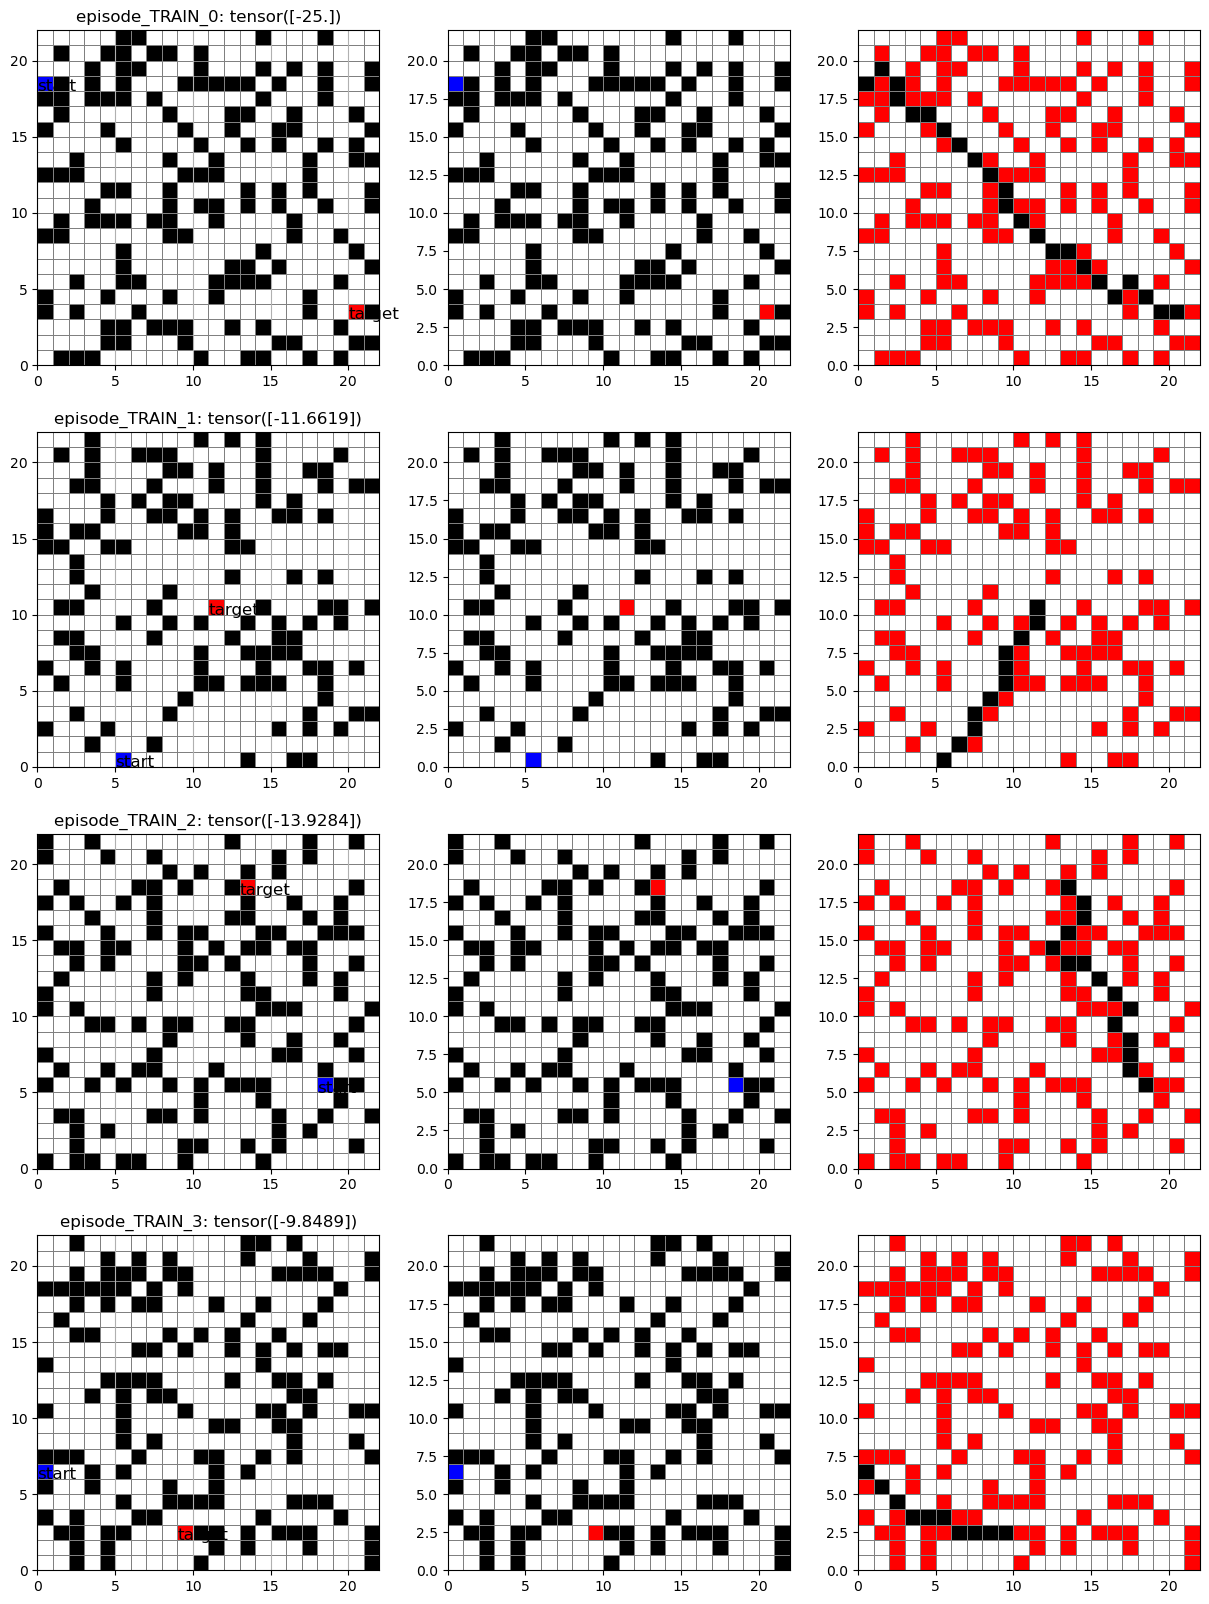

In [3]:
episode_samples = 4
fig, axes = plt.subplots(
    nrows=episode_samples, ncols=3, squeeze=False, figsize=(15, 20)
)

for eidx in range(episode_samples):
    es = train_dataset.get_episode(eidx * config.episode_group_size)
    es.viz(ax=axes[eidx][0], reward_model=reward_model)

    # Viz fov
    fov = es.fov(center_pos=es.agent.start_state.position())
    # print(f"fov: {fov.size()}, {fov}")
    # print(f"fov: {fov}")
    es.viz_fov(ax=axes[eidx][1])
    es.viz_optimal_path(ax=axes[eidx][2])

    es = train_dataset.get_episode(eidx)
    print(f"best_path: {es.best_path}")

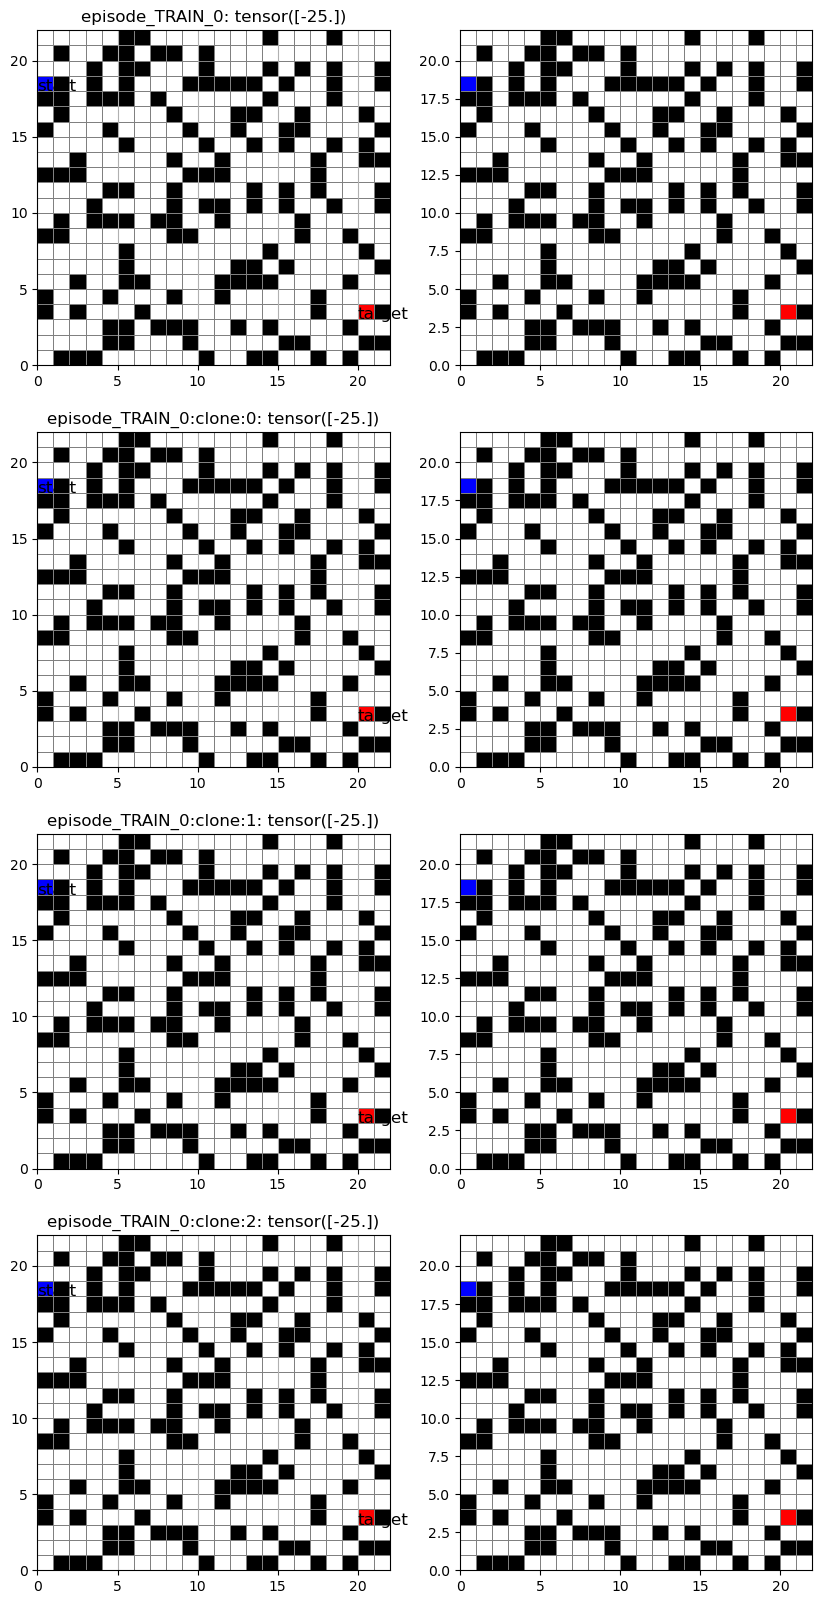

In [4]:
episode_samples = 4
fig, axes = plt.subplots(nrows=episode_samples, ncols=2, figsize=(10, 20))

for eidx in range(episode_samples):
    es = train_dataset.get_episode(eidx)
    es.optimal_path()

    es.viz(ax=axes[eidx][0], reward_model=reward_model)

    # Viz fov
    fov = es.fov(center_pos=es.agent.start_state.position())
    # print(f"fov: {fov.size()}, {fov}")
    # print(f"fov: {fov}")
    es.viz_fov(ax=axes[eidx][1])
plt.show()

# Training Loop
---

In [ ]:
# policy = PolicyFactory.create(
#     policy_mode=PolicyMode.TRANSFORMER_WITH_LATE_POSITION_FUSION, config=config
# ).to(config.device)
pretrain_model_path = (
    "/Users/chengbai/ml/cheng_git/rf_agent/rf_model_policy_20250621094023_pre-train.pt"
)
policy = load_policy_model(
    config=config,
    policy_mode=PolicyMode.TRANSFORMER_WITH_LATE_POSITION_FUSION,
    policy_model_path=pretrain_model_path,
)

reward_model = RewardModel(config=config)
trainer = GRPOTrainer(config=config, policy=policy, reward_model=reward_model)

In [6]:
trainer.policy.img_to_emb.weight.device

device(type='mps', index=0)

TEST:   0%|          | 0/100 [00:00<?, ?it/s]/opt/anaconda3/envs/torch/lib/python3.11/site-packages/torch/nn/functional.py:2434: UserWarning: The operator 'aten::embedding_renorm_' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/mps/MPSFallback.mm:14.)
  torch.embedding_renorm_(weight.detach(), input, max_norm, norm_type)
TEST:  19%|█▉        | 19/100 [00:02<00:09,  8.36it/s]

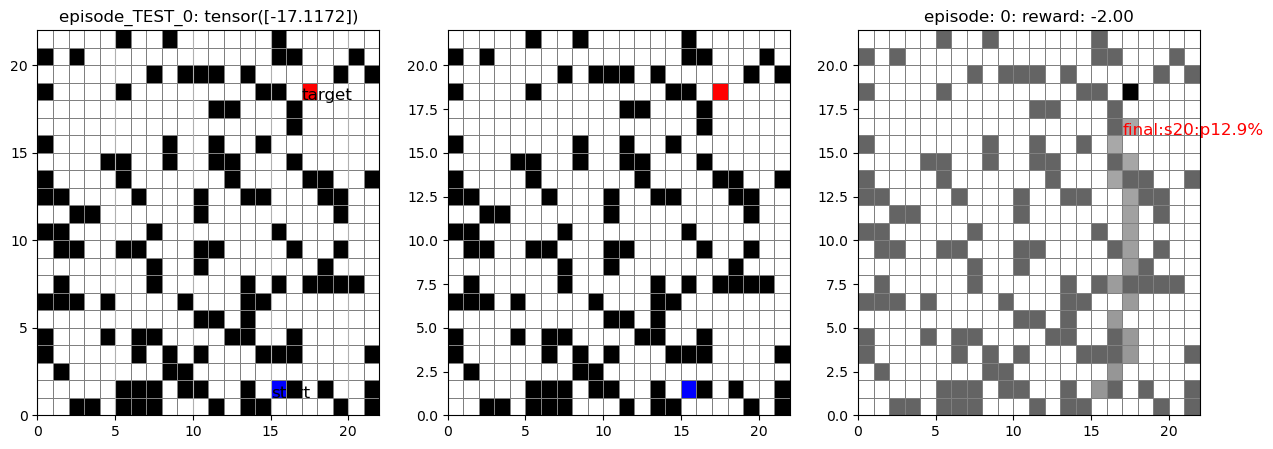

TEST:  39%|███▉      | 39/100 [00:04<00:06,  9.06it/s, split=TEST, batch_idx=19, is_episode_step_done=1, target_episodes=['episode_TEST_0', 'episode_TEST_0:clone:0', 'episode_TEST_0:clone:1', 'episode_TEST_0:clone:2', 'episode_TEST_0:clone:3', 'episode_TEST_0:clone:4', 'episode_TEST_0:clone:5', 'episode_TEST_0:clone:6', 'episode_TEST_1', 'episode_TEST_1:clone:0', 'episode_TEST_1:clone:1', 'episode_TEST_1:clone:2', 'episode_TEST_1:clone:3', 'episode_TEST_1:clone:4', 'episode_TEST_1:clone:5', 'episode_TEST_1:clone:6', 'episode_TEST_2', 'episode_TEST_2:clone:0', 'episode_TEST_2:clone:1', 'episode_TEST_2:clone:2', 'episode_TEST_2:clone:3', 'episode_TEST_2:clone:4', 'episode_TEST_2:clone:5', 'episode_TEST_2:clone:6', 'episode_TEST_3', 'episode_TEST_3:clone:0', 'episode_TEST_3:clone:1', 'episode_TEST_3:clone:2', 'episode_TEST_3:clone:3', 'episode_TEST_3:clone:4', 'episode_TEST_3:clone:5', 'episode_TEST_3:clone:6', 'episode_TEST_4', 'episode_TEST_4:clone:0', 'episode_TEST_4:clone:1', 'episode

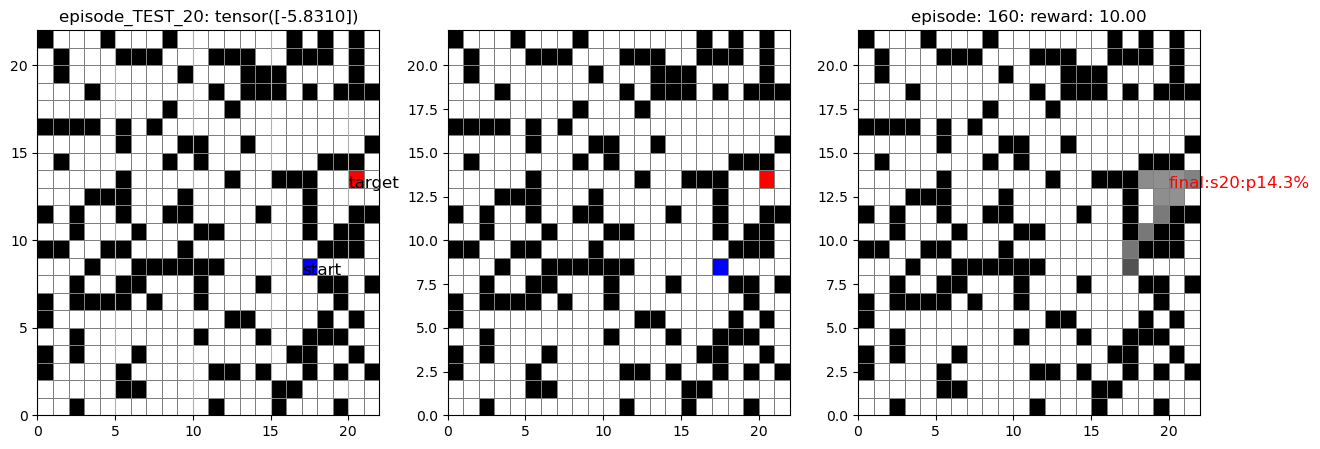

TEST:  59%|█████▉    | 59/100 [00:07<00:04,  9.02it/s, split=TEST, batch_idx=39, is_episode_step_done=1, target_episodes=['episode_TEST_20', 'episode_TEST_20:clone:0', 'episode_TEST_20:clone:1', 'episode_TEST_20:clone:2', 'episode_TEST_20:clone:3', 'episode_TEST_20:clone:4', 'episode_TEST_20:clone:5', 'episode_TEST_20:clone:6', 'episode_TEST_21', 'episode_TEST_21:clone:0', 'episode_TEST_21:clone:1', 'episode_TEST_21:clone:2', 'episode_TEST_21:clone:3', 'episode_TEST_21:clone:4', 'episode_TEST_21:clone:5', 'episode_TEST_21:clone:6', 'episode_TEST_22', 'episode_TEST_22:clone:0', 'episode_TEST_22:clone:1', 'episode_TEST_22:clone:2', 'episode_TEST_22:clone:3', 'episode_TEST_22:clone:4', 'episode_TEST_22:clone:5', 'episode_TEST_22:clone:6', 'episode_TEST_23', 'episode_TEST_23:clone:0', 'episode_TEST_23:clone:1', 'episode_TEST_23:clone:2', 'episode_TEST_23:clone:3', 'episode_TEST_23:clone:4', 'episode_TEST_23:clone:5', 'episode_TEST_23:clone:6', 'episode_TEST_24', 'episode_TEST_24:clone:0', 

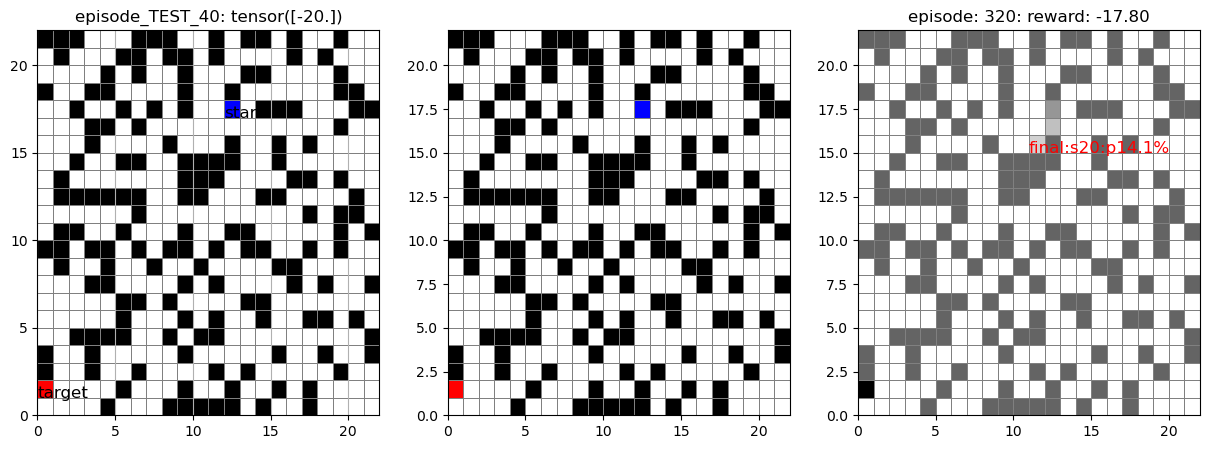

TEST:  79%|███████▉  | 79/100 [00:09<00:02,  8.90it/s, split=TEST, batch_idx=59, is_episode_step_done=1, target_episodes=['episode_TEST_40', 'episode_TEST_40:clone:0', 'episode_TEST_40:clone:1', 'episode_TEST_40:clone:2', 'episode_TEST_40:clone:3', 'episode_TEST_40:clone:4', 'episode_TEST_40:clone:5', 'episode_TEST_40:clone:6', 'episode_TEST_41', 'episode_TEST_41:clone:0', 'episode_TEST_41:clone:1', 'episode_TEST_41:clone:2', 'episode_TEST_41:clone:3', 'episode_TEST_41:clone:4', 'episode_TEST_41:clone:5', 'episode_TEST_41:clone:6', 'episode_TEST_42', 'episode_TEST_42:clone:0', 'episode_TEST_42:clone:1', 'episode_TEST_42:clone:2', 'episode_TEST_42:clone:3', 'episode_TEST_42:clone:4', 'episode_TEST_42:clone:5', 'episode_TEST_42:clone:6', 'episode_TEST_43', 'episode_TEST_43:clone:0', 'episode_TEST_43:clone:1', 'episode_TEST_43:clone:2', 'episode_TEST_43:clone:3', 'episode_TEST_43:clone:4', 'episode_TEST_43:clone:5', 'episode_TEST_43:clone:6', 'episode_TEST_44', 'episode_TEST_44:clone:0', 

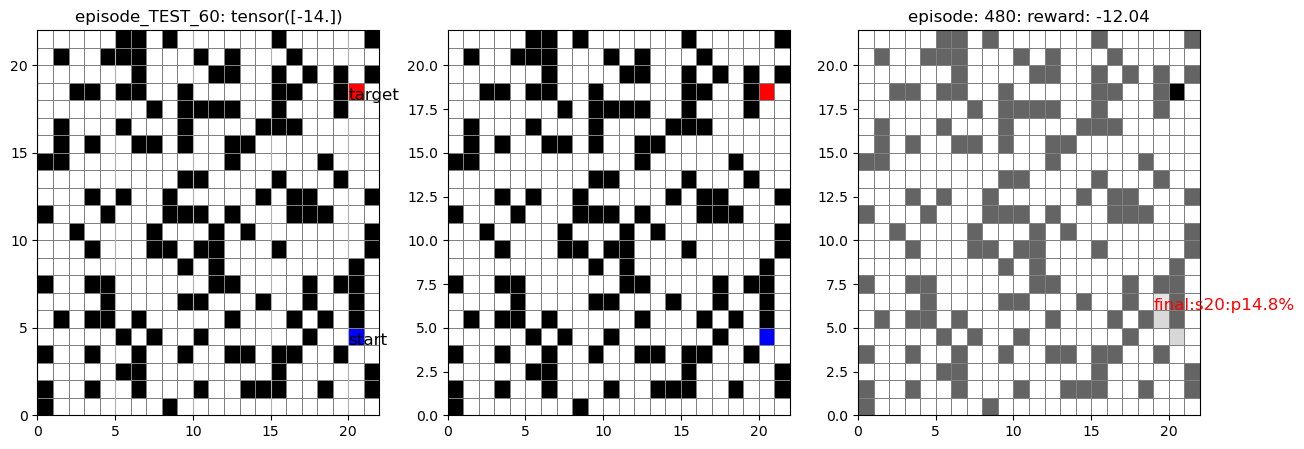

TEST:  99%|█████████▉| 99/100 [00:12<00:00,  8.95it/s, split=TEST, batch_idx=79, is_episode_step_done=1, target_episodes=['episode_TEST_60', 'episode_TEST_60:clone:0', 'episode_TEST_60:clone:1', 'episode_TEST_60:clone:2', 'episode_TEST_60:clone:3', 'episode_TEST_60:clone:4', 'episode_TEST_60:clone:5', 'episode_TEST_60:clone:6', 'episode_TEST_61', 'episode_TEST_61:clone:0', 'episode_TEST_61:clone:1', 'episode_TEST_61:clone:2', 'episode_TEST_61:clone:3', 'episode_TEST_61:clone:4', 'episode_TEST_61:clone:5', 'episode_TEST_61:clone:6', 'episode_TEST_62', 'episode_TEST_62:clone:0', 'episode_TEST_62:clone:1', 'episode_TEST_62:clone:2', 'episode_TEST_62:clone:3', 'episode_TEST_62:clone:4', 'episode_TEST_62:clone:5', 'episode_TEST_62:clone:6', 'episode_TEST_63', 'episode_TEST_63:clone:0', 'episode_TEST_63:clone:1', 'episode_TEST_63:clone:2', 'episode_TEST_63:clone:3', 'episode_TEST_63:clone:4', 'episode_TEST_63:clone:5', 'episode_TEST_63:clone:6', 'episode_TEST_64', 'episode_TEST_64:clone:0', 

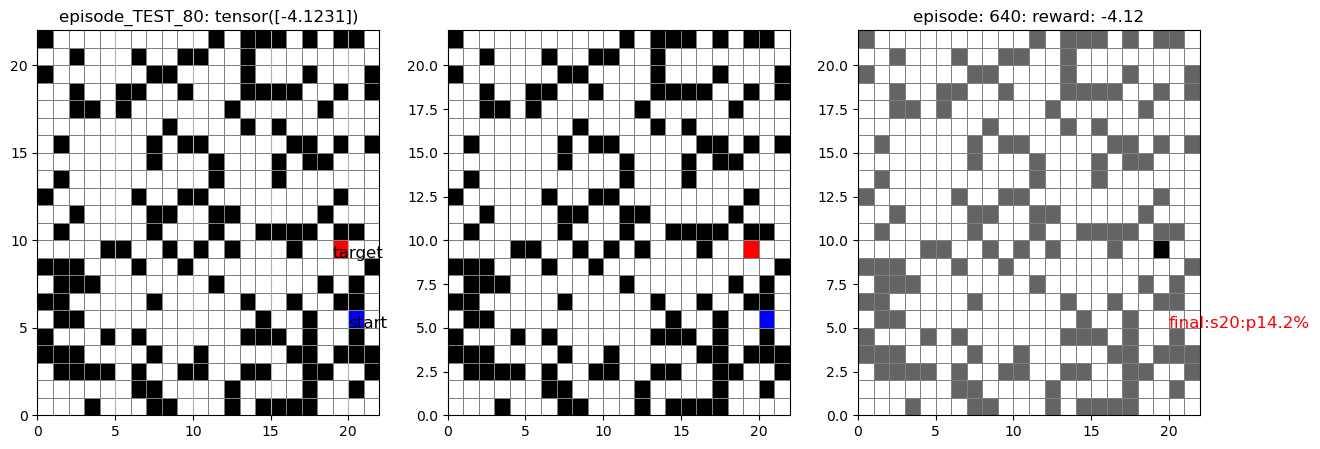

TEST: 100%|██████████| 100/100 [00:12<00:00,  8.19it/s, split=TEST, batch_idx=99, is_episode_step_done=1, target_episodes=['episode_TEST_80', 'episode_TEST_80:clone:0', 'episode_TEST_80:clone:1', 'episode_TEST_80:clone:2', 'episode_TEST_80:clone:3', 'episode_TEST_80:clone:4', 'episode_TEST_80:clone:5', 'episode_TEST_80:clone:6', 'episode_TEST_81', 'episode_TEST_81:clone:0', 'episode_TEST_81:clone:1', 'episode_TEST_81:clone:2', 'episode_TEST_81:clone:3', 'episode_TEST_81:clone:4', 'episode_TEST_81:clone:5', 'episode_TEST_81:clone:6', 'episode_TEST_82', 'episode_TEST_82:clone:0', 'episode_TEST_82:clone:1', 'episode_TEST_82:clone:2', 'episode_TEST_82:clone:3', 'episode_TEST_82:clone:4', 'episode_TEST_82:clone:5', 'episode_TEST_82:clone:6', 'episode_TEST_83', 'episode_TEST_83:clone:0', 'episode_TEST_83:clone:1', 'episode_TEST_83:clone:2', 'episode_TEST_83:clone:3', 'episode_TEST_83:clone:4', 'episode_TEST_83:clone:5', 'episode_TEST_83:clone:6', 'episode_TEST_84', 'episode_TEST_84:clone:0',

In [7]:
inference_and_plot_policy_v2(
    config=config,
    dataset=test_dataset,
    dataloader=test_dataloader,
    policy=policy,
    reward_model=reward_model,
    top_k=2,
)

In [ ]:
# plt.ioff()
trainer.run(
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    train_stage=TrainStage.FINE_TUNE_STAGE_1,
    debug=False,
)

# plt.ion()

train_dataloader: 14000, eval_dataloader: 100


Epoch 1:   0%|          | 0/14000 [00:00<?, ?it/s]/Users/chengbai/ml/cheng_git/rf_agent/src/policy/transformer_model_policy.py:221: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  batch_fov.size(0)
/Users/chengbai/ml/cheng_git/rf_agent/src/policy/transformer_model_policy.py:67: TracerWarning: torch.tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function to create tensors out of constant variables that would be the same every time you call this function. In any other case, this might cause the trace to be incorrect.
  torch.tensor(T, dtype=torch.float, device=self.config.device)
/Users/chengbai/ml/cheng_git/rf_agent/src/policy/transformer_model_policy.py:67: UserWarning: To copy construct from a tensor, it is re

model_path: rf_model_policy_20250622070607.pt
Save policy model to: rf_model_policy_20250622070607.pt


# Evaluate the Model
----

TEST:  19%|█▉        | 19/100 [00:03<00:27,  2.92it/s]

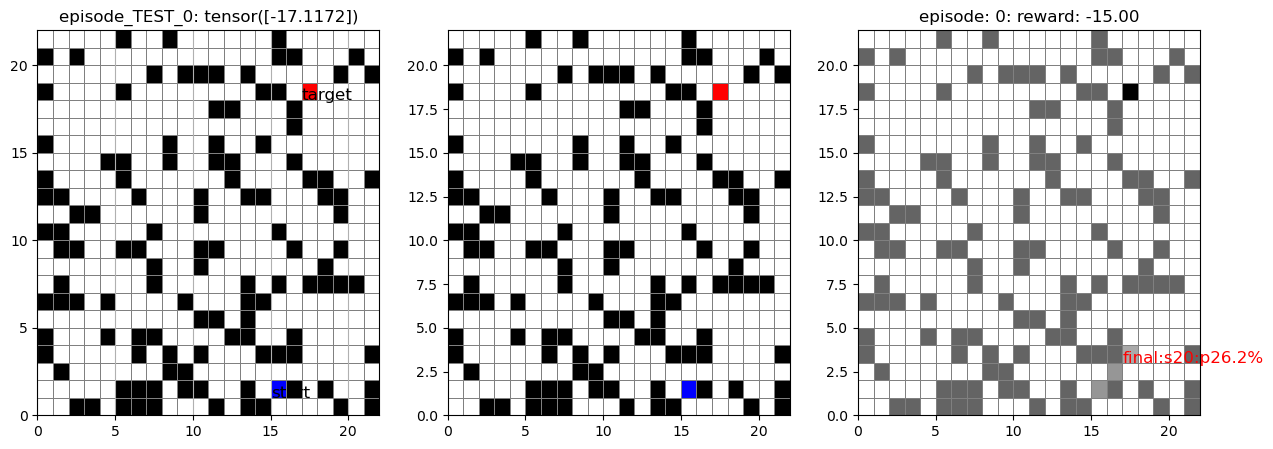

TEST:  39%|███▉      | 39/100 [00:06<00:10,  5.94it/s, split=TEST, batch_idx=19, is_episode_step_done=1, target_episodes=['episode_TEST_0', 'episode_TEST_0:clone:0', 'episode_TEST_0:clone:1', 'episode_TEST_0:clone:2', 'episode_TEST_0:clone:3', 'episode_TEST_0:clone:4', 'episode_TEST_0:clone:5', 'episode_TEST_0:clone:6', 'episode_TEST_1', 'episode_TEST_1:clone:0', 'episode_TEST_1:clone:1', 'episode_TEST_1:clone:2', 'episode_TEST_1:clone:3', 'episode_TEST_1:clone:4', 'episode_TEST_1:clone:5', 'episode_TEST_1:clone:6', 'episode_TEST_2', 'episode_TEST_2:clone:0', 'episode_TEST_2:clone:1', 'episode_TEST_2:clone:2', 'episode_TEST_2:clone:3', 'episode_TEST_2:clone:4', 'episode_TEST_2:clone:5', 'episode_TEST_2:clone:6', 'episode_TEST_3', 'episode_TEST_3:clone:0', 'episode_TEST_3:clone:1', 'episode_TEST_3:clone:2', 'episode_TEST_3:clone:3', 'episode_TEST_3:clone:4', 'episode_TEST_3:clone:5', 'episode_TEST_3:clone:6', 'episode_TEST_4', 'episode_TEST_4:clone:0', 'episode_TEST_4:clone:1', 'episode

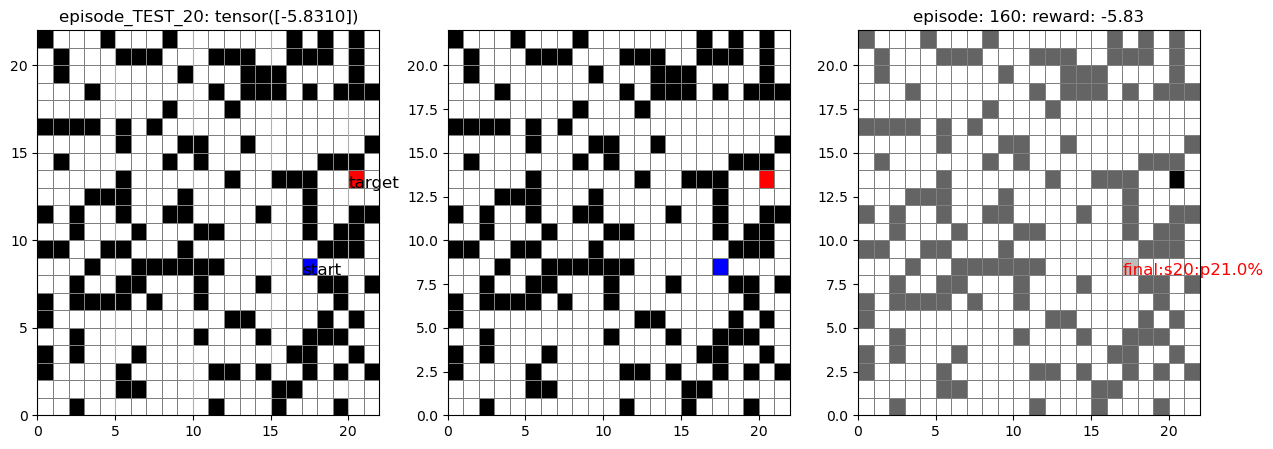

TEST:  59%|█████▉    | 59/100 [00:09<00:06,  6.59it/s, split=TEST, batch_idx=39, is_episode_step_done=1, target_episodes=['episode_TEST_20', 'episode_TEST_20:clone:0', 'episode_TEST_20:clone:1', 'episode_TEST_20:clone:2', 'episode_TEST_20:clone:3', 'episode_TEST_20:clone:4', 'episode_TEST_20:clone:5', 'episode_TEST_20:clone:6', 'episode_TEST_21', 'episode_TEST_21:clone:0', 'episode_TEST_21:clone:1', 'episode_TEST_21:clone:2', 'episode_TEST_21:clone:3', 'episode_TEST_21:clone:4', 'episode_TEST_21:clone:5', 'episode_TEST_21:clone:6', 'episode_TEST_22', 'episode_TEST_22:clone:0', 'episode_TEST_22:clone:1', 'episode_TEST_22:clone:2', 'episode_TEST_22:clone:3', 'episode_TEST_22:clone:4', 'episode_TEST_22:clone:5', 'episode_TEST_22:clone:6', 'episode_TEST_23', 'episode_TEST_23:clone:0', 'episode_TEST_23:clone:1', 'episode_TEST_23:clone:2', 'episode_TEST_23:clone:3', 'episode_TEST_23:clone:4', 'episode_TEST_23:clone:5', 'episode_TEST_23:clone:6', 'episode_TEST_24', 'episode_TEST_24:clone:0', 

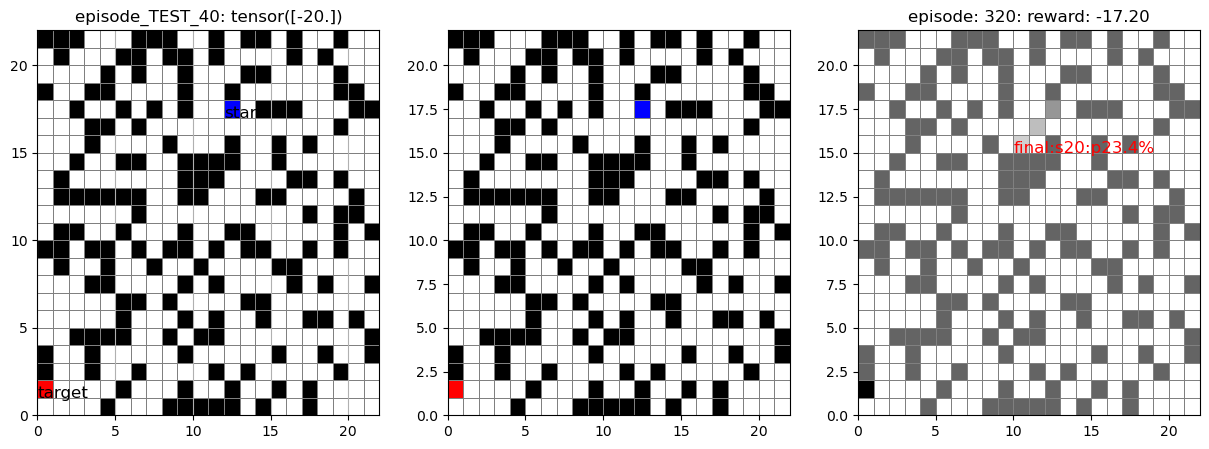

TEST:  79%|███████▉  | 79/100 [00:12<00:03,  6.43it/s, split=TEST, batch_idx=59, is_episode_step_done=1, target_episodes=['episode_TEST_40', 'episode_TEST_40:clone:0', 'episode_TEST_40:clone:1', 'episode_TEST_40:clone:2', 'episode_TEST_40:clone:3', 'episode_TEST_40:clone:4', 'episode_TEST_40:clone:5', 'episode_TEST_40:clone:6', 'episode_TEST_41', 'episode_TEST_41:clone:0', 'episode_TEST_41:clone:1', 'episode_TEST_41:clone:2', 'episode_TEST_41:clone:3', 'episode_TEST_41:clone:4', 'episode_TEST_41:clone:5', 'episode_TEST_41:clone:6', 'episode_TEST_42', 'episode_TEST_42:clone:0', 'episode_TEST_42:clone:1', 'episode_TEST_42:clone:2', 'episode_TEST_42:clone:3', 'episode_TEST_42:clone:4', 'episode_TEST_42:clone:5', 'episode_TEST_42:clone:6', 'episode_TEST_43', 'episode_TEST_43:clone:0', 'episode_TEST_43:clone:1', 'episode_TEST_43:clone:2', 'episode_TEST_43:clone:3', 'episode_TEST_43:clone:4', 'episode_TEST_43:clone:5', 'episode_TEST_43:clone:6', 'episode_TEST_44', 'episode_TEST_44:clone:0', 

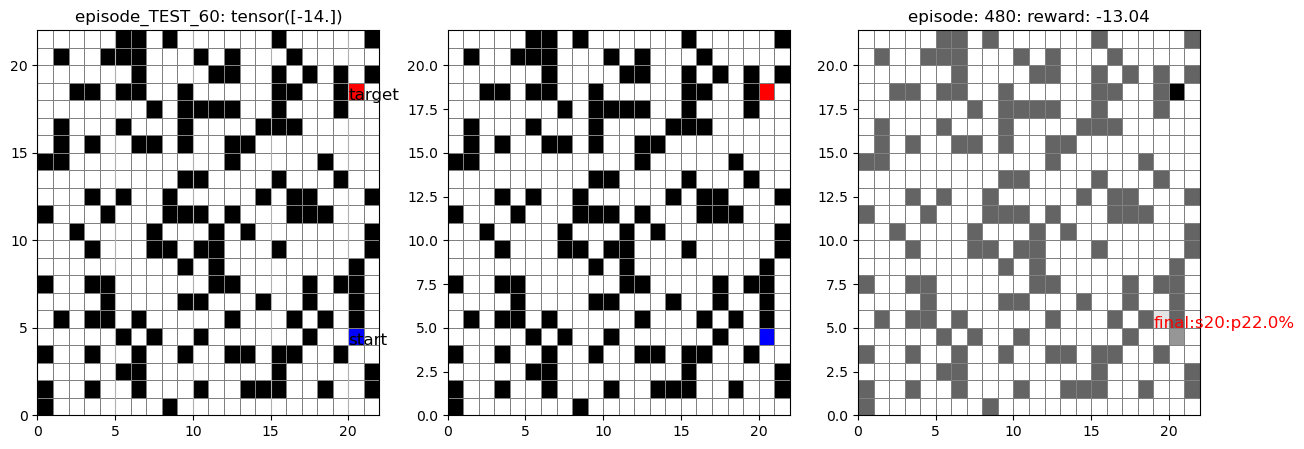

TEST:  99%|█████████▉| 99/100 [00:14<00:00,  6.57it/s, split=TEST, batch_idx=79, is_episode_step_done=1, target_episodes=['episode_TEST_60', 'episode_TEST_60:clone:0', 'episode_TEST_60:clone:1', 'episode_TEST_60:clone:2', 'episode_TEST_60:clone:3', 'episode_TEST_60:clone:4', 'episode_TEST_60:clone:5', 'episode_TEST_60:clone:6', 'episode_TEST_61', 'episode_TEST_61:clone:0', 'episode_TEST_61:clone:1', 'episode_TEST_61:clone:2', 'episode_TEST_61:clone:3', 'episode_TEST_61:clone:4', 'episode_TEST_61:clone:5', 'episode_TEST_61:clone:6', 'episode_TEST_62', 'episode_TEST_62:clone:0', 'episode_TEST_62:clone:1', 'episode_TEST_62:clone:2', 'episode_TEST_62:clone:3', 'episode_TEST_62:clone:4', 'episode_TEST_62:clone:5', 'episode_TEST_62:clone:6', 'episode_TEST_63', 'episode_TEST_63:clone:0', 'episode_TEST_63:clone:1', 'episode_TEST_63:clone:2', 'episode_TEST_63:clone:3', 'episode_TEST_63:clone:4', 'episode_TEST_63:clone:5', 'episode_TEST_63:clone:6', 'episode_TEST_64', 'episode_TEST_64:clone:0', 

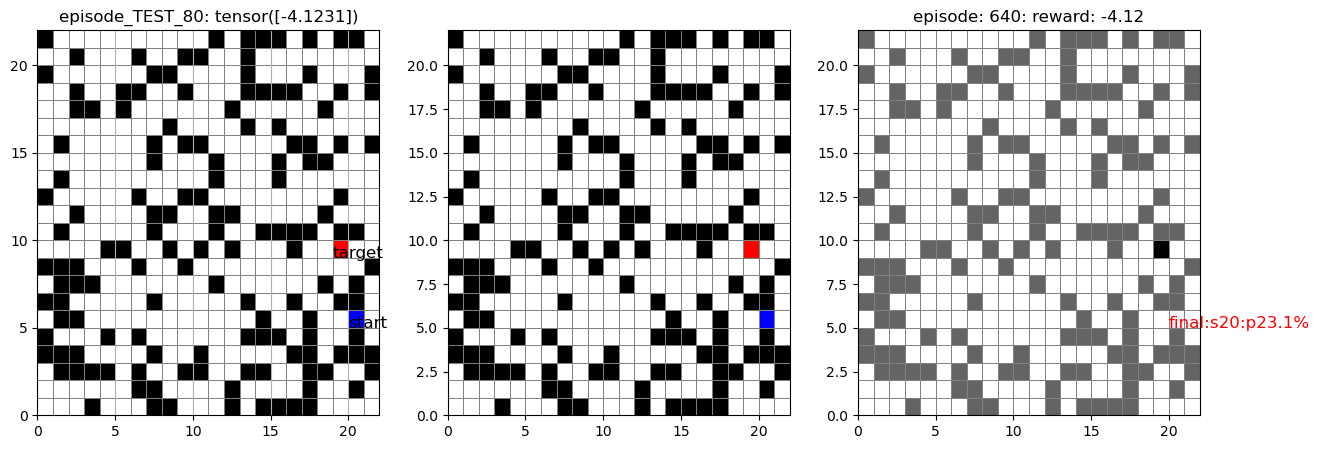

TEST: 100%|██████████| 100/100 [00:15<00:00,  6.57it/s, split=TEST, batch_idx=99, is_episode_step_done=1, target_episodes=['episode_TEST_80', 'episode_TEST_80:clone:0', 'episode_TEST_80:clone:1', 'episode_TEST_80:clone:2', 'episode_TEST_80:clone:3', 'episode_TEST_80:clone:4', 'episode_TEST_80:clone:5', 'episode_TEST_80:clone:6', 'episode_TEST_81', 'episode_TEST_81:clone:0', 'episode_TEST_81:clone:1', 'episode_TEST_81:clone:2', 'episode_TEST_81:clone:3', 'episode_TEST_81:clone:4', 'episode_TEST_81:clone:5', 'episode_TEST_81:clone:6', 'episode_TEST_82', 'episode_TEST_82:clone:0', 'episode_TEST_82:clone:1', 'episode_TEST_82:clone:2', 'episode_TEST_82:clone:3', 'episode_TEST_82:clone:4', 'episode_TEST_82:clone:5', 'episode_TEST_82:clone:6', 'episode_TEST_83', 'episode_TEST_83:clone:0', 'episode_TEST_83:clone:1', 'episode_TEST_83:clone:2', 'episode_TEST_83:clone:3', 'episode_TEST_83:clone:4', 'episode_TEST_83:clone:5', 'episode_TEST_83:clone:6', 'episode_TEST_84', 'episode_TEST_84:clone:0',

In [10]:
inference_and_plot_policy_v2(
    config=config,
    dataset=test_dataset,
    dataloader=test_dataloader,
    policy=policy,
    reward_model=reward_model,
    top_k=1,
)

EVAL:   0%|          | 0/100 [00:00<?, ?it/s]

EVAL:  19%|█▉        | 19/100 [00:13<01:01,  1.31it/s]

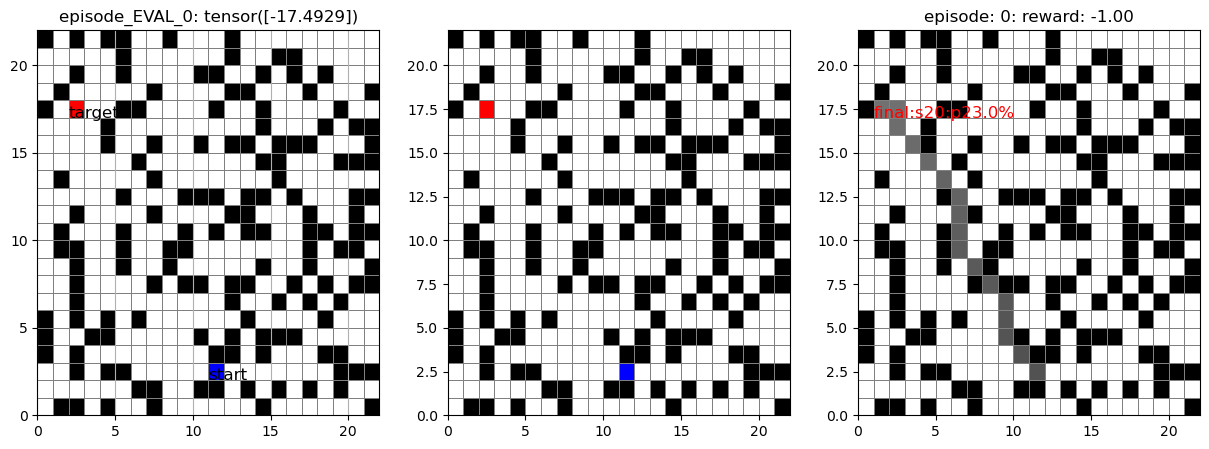

EVAL:  39%|███▉      | 39/100 [00:32<00:42,  1.45it/s, split=EVAL, batch_idx=19, is_episode_step_done=1, target_episodes=['episode_EVAL_0', 'episode_EVAL_0:clone:0', 'episode_EVAL_0:clone:1', 'episode_EVAL_0:clone:2', 'episode_EVAL_0:clone:3', 'episode_EVAL_0:clone:4', 'episode_EVAL_0:clone:5', 'episode_EVAL_0:clone:6', 'episode_EVAL_1', 'episode_EVAL_1:clone:0', 'episode_EVAL_1:clone:1', 'episode_EVAL_1:clone:2', 'episode_EVAL_1:clone:3', 'episode_EVAL_1:clone:4', 'episode_EVAL_1:clone:5', 'episode_EVAL_1:clone:6', 'episode_EVAL_2', 'episode_EVAL_2:clone:0', 'episode_EVAL_2:clone:1', 'episode_EVAL_2:clone:2', 'episode_EVAL_2:clone:3', 'episode_EVAL_2:clone:4', 'episode_EVAL_2:clone:5', 'episode_EVAL_2:clone:6', 'episode_EVAL_3', 'episode_EVAL_3:clone:0', 'episode_EVAL_3:clone:1', 'episode_EVAL_3:clone:2', 'episode_EVAL_3:clone:3', 'episode_EVAL_3:clone:4', 'episode_EVAL_3:clone:5', 'episode_EVAL_3:clone:6', 'episode_EVAL_4', 'episode_EVAL_4:clone:0', 'episode_EVAL_4:clone:1', 'episode

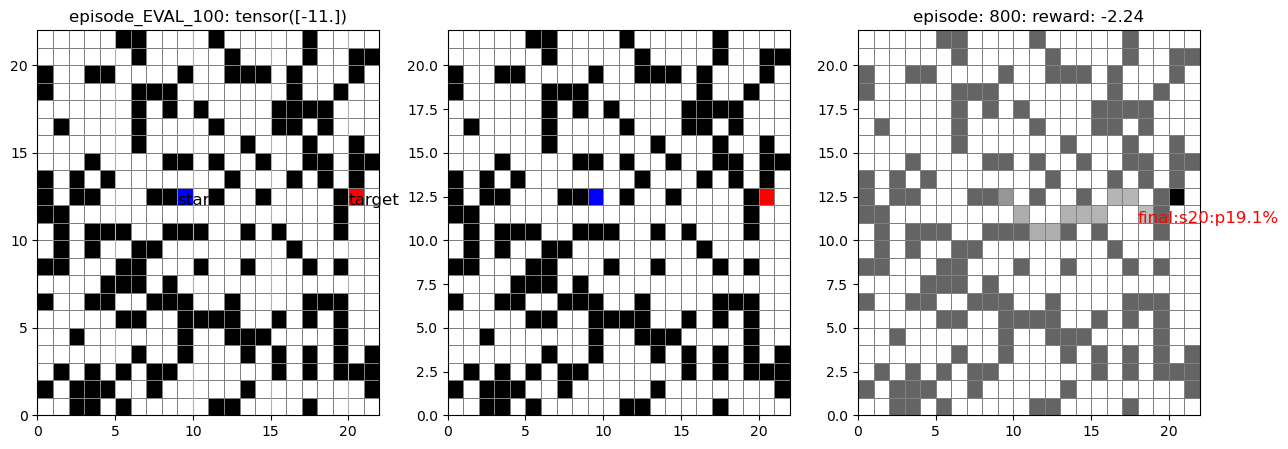

EVAL:  59%|█████▉    | 59/100 [00:48<00:26,  1.56it/s, split=EVAL, batch_idx=39, is_episode_step_done=1, target_episodes=['episode_EVAL_100', 'episode_EVAL_100:clone:0', 'episode_EVAL_100:clone:1', 'episode_EVAL_100:clone:2', 'episode_EVAL_100:clone:3', 'episode_EVAL_100:clone:4', 'episode_EVAL_100:clone:5', 'episode_EVAL_100:clone:6', 'episode_EVAL_101', 'episode_EVAL_101:clone:0', 'episode_EVAL_101:clone:1', 'episode_EVAL_101:clone:2', 'episode_EVAL_101:clone:3', 'episode_EVAL_101:clone:4', 'episode_EVAL_101:clone:5', 'episode_EVAL_101:clone:6', 'episode_EVAL_102', 'episode_EVAL_102:clone:0', 'episode_EVAL_102:clone:1', 'episode_EVAL_102:clone:2', 'episode_EVAL_102:clone:3', 'episode_EVAL_102:clone:4', 'episode_EVAL_102:clone:5', 'episode_EVAL_102:clone:6', 'episode_EVAL_103', 'episode_EVAL_103:clone:0', 'episode_EVAL_103:clone:1', 'episode_EVAL_103:clone:2', 'episode_EVAL_103:clone:3', 'episode_EVAL_103:clone:4', 'episode_EVAL_103:clone:5', 'episode_EVAL_103:clone:6', 'episode_EVAL_

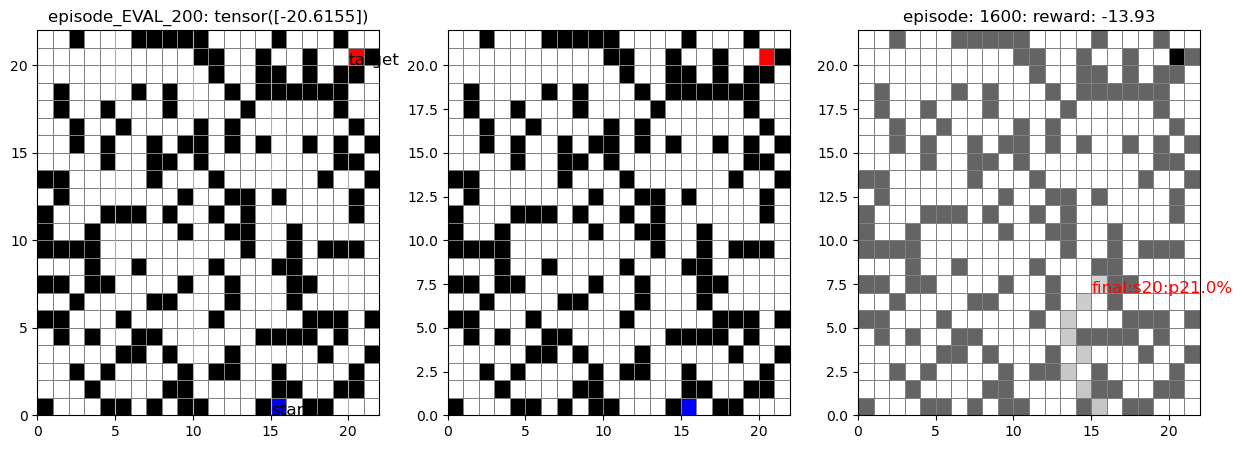

EVAL:  79%|███████▉  | 79/100 [01:02<00:14,  1.44it/s, split=EVAL, batch_idx=59, is_episode_step_done=1, target_episodes=['episode_EVAL_200', 'episode_EVAL_200:clone:0', 'episode_EVAL_200:clone:1', 'episode_EVAL_200:clone:2', 'episode_EVAL_200:clone:3', 'episode_EVAL_200:clone:4', 'episode_EVAL_200:clone:5', 'episode_EVAL_200:clone:6', 'episode_EVAL_201', 'episode_EVAL_201:clone:0', 'episode_EVAL_201:clone:1', 'episode_EVAL_201:clone:2', 'episode_EVAL_201:clone:3', 'episode_EVAL_201:clone:4', 'episode_EVAL_201:clone:5', 'episode_EVAL_201:clone:6', 'episode_EVAL_202', 'episode_EVAL_202:clone:0', 'episode_EVAL_202:clone:1', 'episode_EVAL_202:clone:2', 'episode_EVAL_202:clone:3', 'episode_EVAL_202:clone:4', 'episode_EVAL_202:clone:5', 'episode_EVAL_202:clone:6', 'episode_EVAL_203', 'episode_EVAL_203:clone:0', 'episode_EVAL_203:clone:1', 'episode_EVAL_203:clone:2', 'episode_EVAL_203:clone:3', 'episode_EVAL_203:clone:4', 'episode_EVAL_203:clone:5', 'episode_EVAL_203:clone:6', 'episode_EVAL_

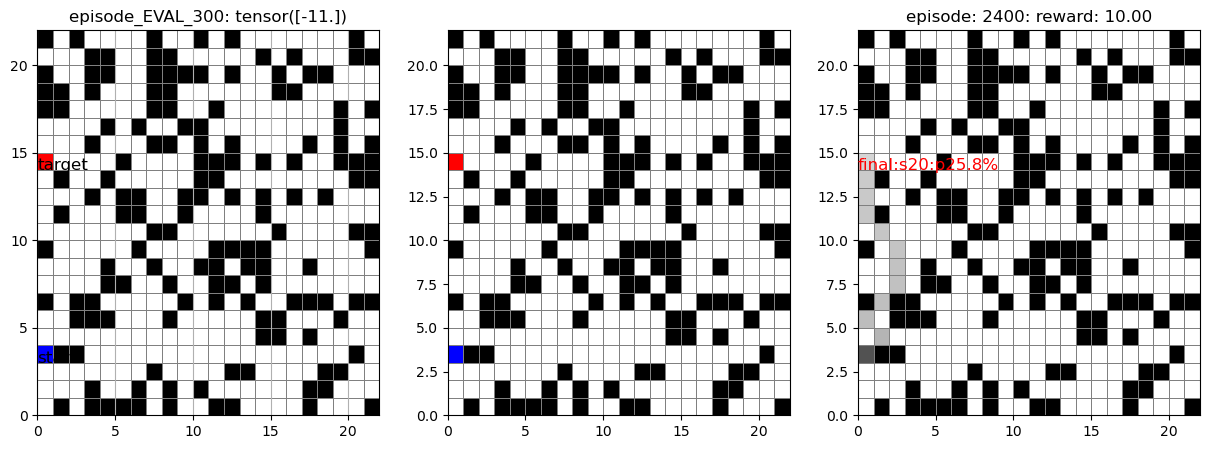

EVAL:  99%|█████████▉| 99/100 [01:19<00:00,  1.35it/s, split=EVAL, batch_idx=79, is_episode_step_done=1, target_episodes=['episode_EVAL_300', 'episode_EVAL_300:clone:0', 'episode_EVAL_300:clone:1', 'episode_EVAL_300:clone:2', 'episode_EVAL_300:clone:3', 'episode_EVAL_300:clone:4', 'episode_EVAL_300:clone:5', 'episode_EVAL_300:clone:6', 'episode_EVAL_301', 'episode_EVAL_301:clone:0', 'episode_EVAL_301:clone:1', 'episode_EVAL_301:clone:2', 'episode_EVAL_301:clone:3', 'episode_EVAL_301:clone:4', 'episode_EVAL_301:clone:5', 'episode_EVAL_301:clone:6', 'episode_EVAL_302', 'episode_EVAL_302:clone:0', 'episode_EVAL_302:clone:1', 'episode_EVAL_302:clone:2', 'episode_EVAL_302:clone:3', 'episode_EVAL_302:clone:4', 'episode_EVAL_302:clone:5', 'episode_EVAL_302:clone:6', 'episode_EVAL_303', 'episode_EVAL_303:clone:0', 'episode_EVAL_303:clone:1', 'episode_EVAL_303:clone:2', 'episode_EVAL_303:clone:3', 'episode_EVAL_303:clone:4', 'episode_EVAL_303:clone:5', 'episode_EVAL_303:clone:6', 'episode_EVAL_

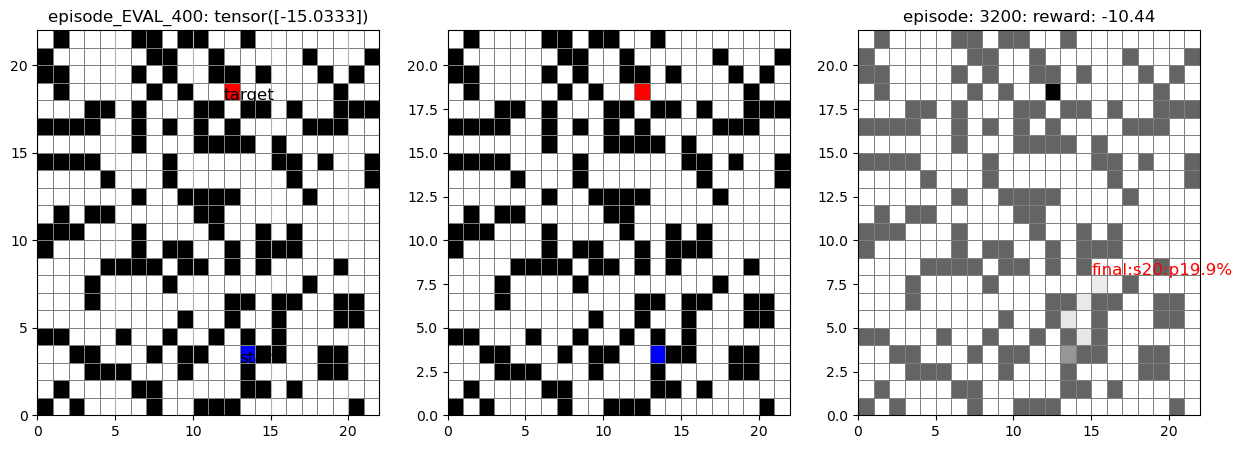

EVAL: 100%|██████████| 100/100 [01:20<00:00,  1.24it/s, split=EVAL, batch_idx=99, is_episode_step_done=1, target_episodes=['episode_EVAL_400', 'episode_EVAL_400:clone:0', 'episode_EVAL_400:clone:1', 'episode_EVAL_400:clone:2', 'episode_EVAL_400:clone:3', 'episode_EVAL_400:clone:4', 'episode_EVAL_400:clone:5', 'episode_EVAL_400:clone:6', 'episode_EVAL_401', 'episode_EVAL_401:clone:0', 'episode_EVAL_401:clone:1', 'episode_EVAL_401:clone:2', 'episode_EVAL_401:clone:3', 'episode_EVAL_401:clone:4', 'episode_EVAL_401:clone:5', 'episode_EVAL_401:clone:6', 'episode_EVAL_402', 'episode_EVAL_402:clone:0', 'episode_EVAL_402:clone:1', 'episode_EVAL_402:clone:2', 'episode_EVAL_402:clone:3', 'episode_EVAL_402:clone:4', 'episode_EVAL_402:clone:5', 'episode_EVAL_402:clone:6', 'episode_EVAL_403', 'episode_EVAL_403:clone:0', 'episode_EVAL_403:clone:1', 'episode_EVAL_403:clone:2', 'episode_EVAL_403:clone:3', 'episode_EVAL_403:clone:4', 'episode_EVAL_403:clone:5', 'episode_EVAL_403:clone:6', 'episode_EVAL

In [19]:
inference_and_plot_policy_v2(
    config=config,
    dataset=eval_dataset,  # test_dataset,
    dataloader=eval_dataloader,  # test_dataloader,
    policy=policy,
    reward_model=reward_model,
    top_k=2,
)

EVAL:  19%|█▉        | 19/100 [00:15<00:51,  1.59it/s]

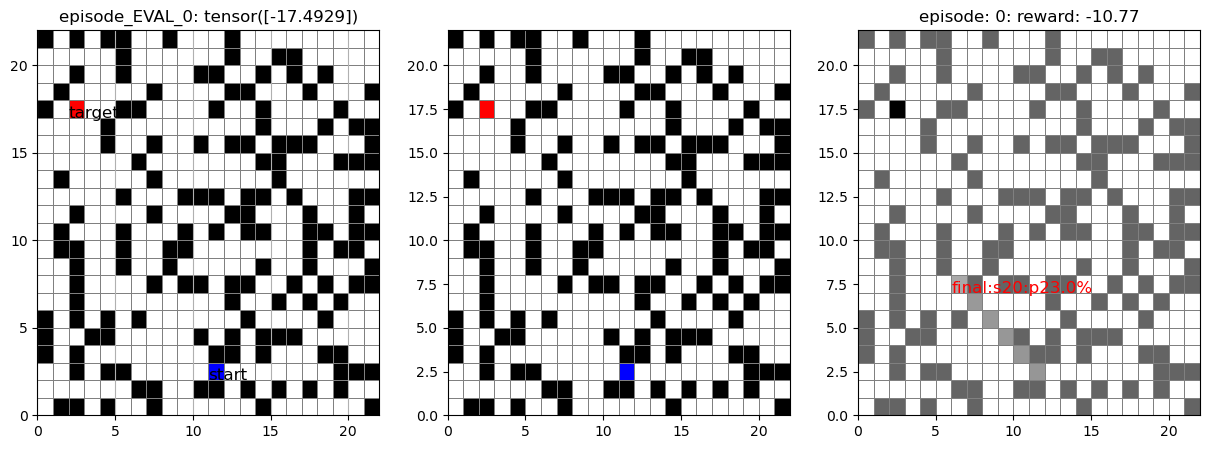

EVAL:  39%|███▉      | 39/100 [00:29<00:38,  1.57it/s, split=EVAL, batch_idx=19, is_episode_step_done=1, target_episodes=['episode_EVAL_0', 'episode_EVAL_0:clone:0', 'episode_EVAL_0:clone:1', 'episode_EVAL_0:clone:2', 'episode_EVAL_0:clone:3', 'episode_EVAL_0:clone:4', 'episode_EVAL_0:clone:5', 'episode_EVAL_0:clone:6', 'episode_EVAL_1', 'episode_EVAL_1:clone:0', 'episode_EVAL_1:clone:1', 'episode_EVAL_1:clone:2', 'episode_EVAL_1:clone:3', 'episode_EVAL_1:clone:4', 'episode_EVAL_1:clone:5', 'episode_EVAL_1:clone:6', 'episode_EVAL_2', 'episode_EVAL_2:clone:0', 'episode_EVAL_2:clone:1', 'episode_EVAL_2:clone:2', 'episode_EVAL_2:clone:3', 'episode_EVAL_2:clone:4', 'episode_EVAL_2:clone:5', 'episode_EVAL_2:clone:6', 'episode_EVAL_3', 'episode_EVAL_3:clone:0', 'episode_EVAL_3:clone:1', 'episode_EVAL_3:clone:2', 'episode_EVAL_3:clone:3', 'episode_EVAL_3:clone:4', 'episode_EVAL_3:clone:5', 'episode_EVAL_3:clone:6', 'episode_EVAL_4', 'episode_EVAL_4:clone:0', 'episode_EVAL_4:clone:1', 'episode

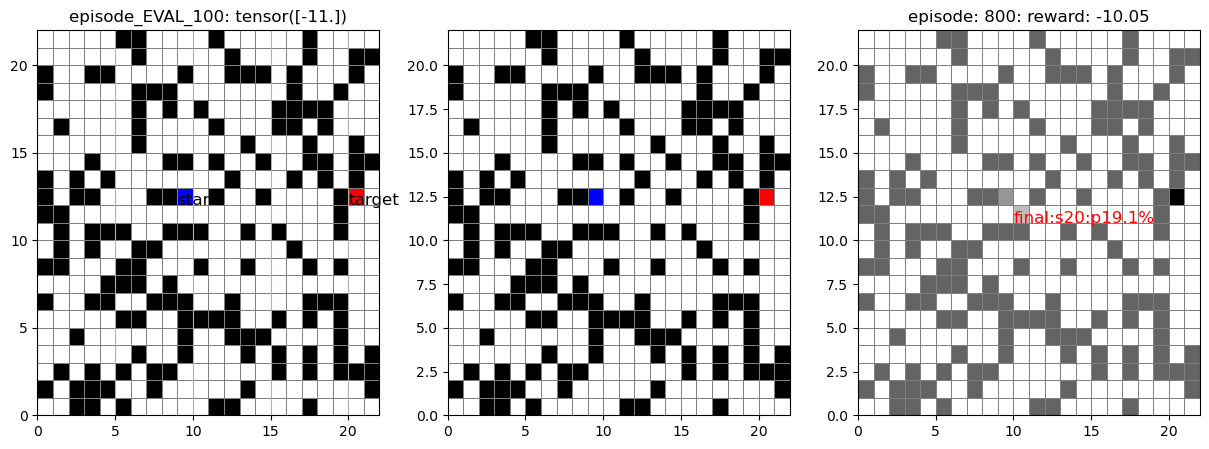

EVAL:  59%|█████▉    | 59/100 [00:43<00:25,  1.60it/s, split=EVAL, batch_idx=39, is_episode_step_done=1, target_episodes=['episode_EVAL_100', 'episode_EVAL_100:clone:0', 'episode_EVAL_100:clone:1', 'episode_EVAL_100:clone:2', 'episode_EVAL_100:clone:3', 'episode_EVAL_100:clone:4', 'episode_EVAL_100:clone:5', 'episode_EVAL_100:clone:6', 'episode_EVAL_101', 'episode_EVAL_101:clone:0', 'episode_EVAL_101:clone:1', 'episode_EVAL_101:clone:2', 'episode_EVAL_101:clone:3', 'episode_EVAL_101:clone:4', 'episode_EVAL_101:clone:5', 'episode_EVAL_101:clone:6', 'episode_EVAL_102', 'episode_EVAL_102:clone:0', 'episode_EVAL_102:clone:1', 'episode_EVAL_102:clone:2', 'episode_EVAL_102:clone:3', 'episode_EVAL_102:clone:4', 'episode_EVAL_102:clone:5', 'episode_EVAL_102:clone:6', 'episode_EVAL_103', 'episode_EVAL_103:clone:0', 'episode_EVAL_103:clone:1', 'episode_EVAL_103:clone:2', 'episode_EVAL_103:clone:3', 'episode_EVAL_103:clone:4', 'episode_EVAL_103:clone:5', 'episode_EVAL_103:clone:6', 'episode_EVAL_

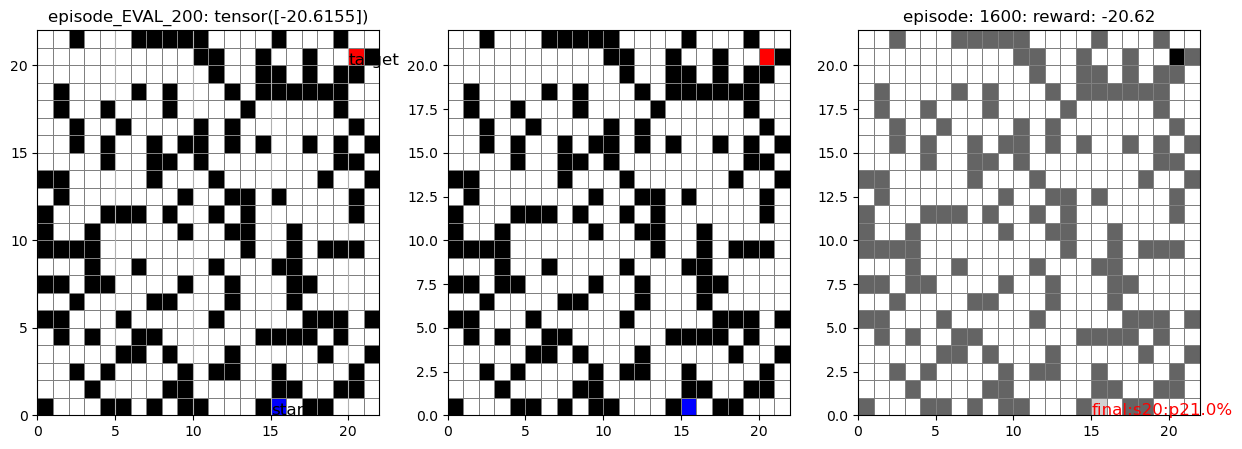

EVAL:  79%|███████▉  | 79/100 [00:56<00:13,  1.56it/s, split=EVAL, batch_idx=59, is_episode_step_done=1, target_episodes=['episode_EVAL_200', 'episode_EVAL_200:clone:0', 'episode_EVAL_200:clone:1', 'episode_EVAL_200:clone:2', 'episode_EVAL_200:clone:3', 'episode_EVAL_200:clone:4', 'episode_EVAL_200:clone:5', 'episode_EVAL_200:clone:6', 'episode_EVAL_201', 'episode_EVAL_201:clone:0', 'episode_EVAL_201:clone:1', 'episode_EVAL_201:clone:2', 'episode_EVAL_201:clone:3', 'episode_EVAL_201:clone:4', 'episode_EVAL_201:clone:5', 'episode_EVAL_201:clone:6', 'episode_EVAL_202', 'episode_EVAL_202:clone:0', 'episode_EVAL_202:clone:1', 'episode_EVAL_202:clone:2', 'episode_EVAL_202:clone:3', 'episode_EVAL_202:clone:4', 'episode_EVAL_202:clone:5', 'episode_EVAL_202:clone:6', 'episode_EVAL_203', 'episode_EVAL_203:clone:0', 'episode_EVAL_203:clone:1', 'episode_EVAL_203:clone:2', 'episode_EVAL_203:clone:3', 'episode_EVAL_203:clone:4', 'episode_EVAL_203:clone:5', 'episode_EVAL_203:clone:6', 'episode_EVAL_

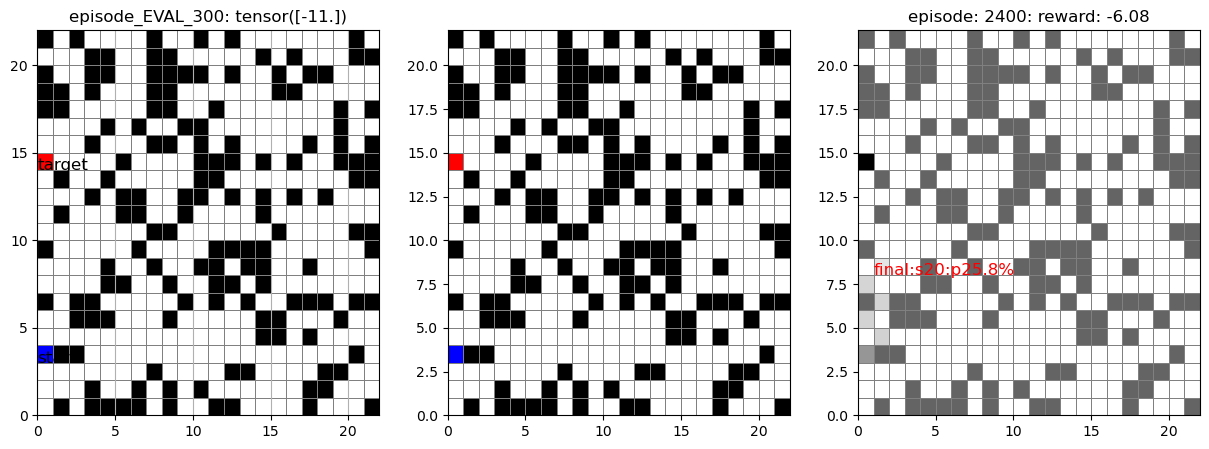

EVAL:  99%|█████████▉| 99/100 [01:11<00:00,  1.47it/s, split=EVAL, batch_idx=79, is_episode_step_done=1, target_episodes=['episode_EVAL_300', 'episode_EVAL_300:clone:0', 'episode_EVAL_300:clone:1', 'episode_EVAL_300:clone:2', 'episode_EVAL_300:clone:3', 'episode_EVAL_300:clone:4', 'episode_EVAL_300:clone:5', 'episode_EVAL_300:clone:6', 'episode_EVAL_301', 'episode_EVAL_301:clone:0', 'episode_EVAL_301:clone:1', 'episode_EVAL_301:clone:2', 'episode_EVAL_301:clone:3', 'episode_EVAL_301:clone:4', 'episode_EVAL_301:clone:5', 'episode_EVAL_301:clone:6', 'episode_EVAL_302', 'episode_EVAL_302:clone:0', 'episode_EVAL_302:clone:1', 'episode_EVAL_302:clone:2', 'episode_EVAL_302:clone:3', 'episode_EVAL_302:clone:4', 'episode_EVAL_302:clone:5', 'episode_EVAL_302:clone:6', 'episode_EVAL_303', 'episode_EVAL_303:clone:0', 'episode_EVAL_303:clone:1', 'episode_EVAL_303:clone:2', 'episode_EVAL_303:clone:3', 'episode_EVAL_303:clone:4', 'episode_EVAL_303:clone:5', 'episode_EVAL_303:clone:6', 'episode_EVAL_

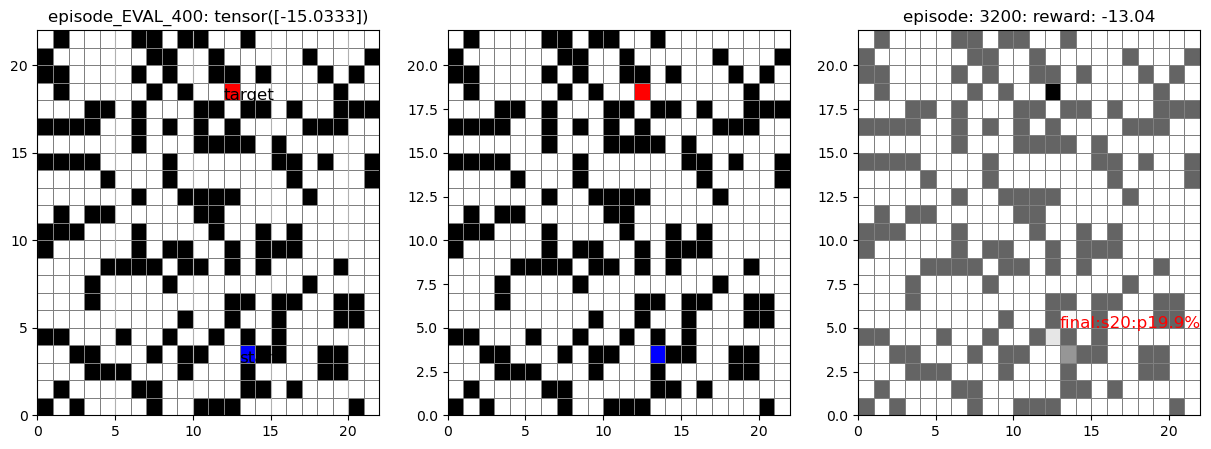

EVAL: 100%|██████████| 100/100 [01:12<00:00,  1.39it/s, split=EVAL, batch_idx=99, is_episode_step_done=1, target_episodes=['episode_EVAL_400', 'episode_EVAL_400:clone:0', 'episode_EVAL_400:clone:1', 'episode_EVAL_400:clone:2', 'episode_EVAL_400:clone:3', 'episode_EVAL_400:clone:4', 'episode_EVAL_400:clone:5', 'episode_EVAL_400:clone:6', 'episode_EVAL_401', 'episode_EVAL_401:clone:0', 'episode_EVAL_401:clone:1', 'episode_EVAL_401:clone:2', 'episode_EVAL_401:clone:3', 'episode_EVAL_401:clone:4', 'episode_EVAL_401:clone:5', 'episode_EVAL_401:clone:6', 'episode_EVAL_402', 'episode_EVAL_402:clone:0', 'episode_EVAL_402:clone:1', 'episode_EVAL_402:clone:2', 'episode_EVAL_402:clone:3', 'episode_EVAL_402:clone:4', 'episode_EVAL_402:clone:5', 'episode_EVAL_402:clone:6', 'episode_EVAL_403', 'episode_EVAL_403:clone:0', 'episode_EVAL_403:clone:1', 'episode_EVAL_403:clone:2', 'episode_EVAL_403:clone:3', 'episode_EVAL_403:clone:4', 'episode_EVAL_403:clone:5', 'episode_EVAL_403:clone:6', 'episode_EVAL

In [20]:
inference_and_plot_policy_v2(
    config=config,
    dataset=eval_dataset,  # test_dataset,
    dataloader=eval_dataloader,  # test_dataloader,
    policy=policy,
    reward_model=reward_model,
    top_k=1,
)